# PWC Results

Build the PWC cross-seed LaTeX table and seed-6 plots from saved result files. This notebook does not evaluate networks again.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.base.result import BaseResult
from src.scenarios.pwc.constraint import Constraint
from src.scenarios.pwc.system import System
from src.scenarios.pwc.visualization import Visualization
from src.utils.config import Config
from src.utils.result import build_average_table, discover_seeds

torch.set_default_dtype(torch.float64)

RESULT_ROOT = REPO_ROOT / "results" / "pwc"
print("Available runs:", sorted(path.name for path in RESULT_ROOT.glob("*") if path.is_dir()))

DIR_NAME = "final"
RUN_DIR = RESULT_ROOT / DIR_NAME
OUTPUT_DIR = RUN_DIR

METHODS = ["NN", "HardNet", "CAffNet-FF", "CAffNet-TF"]
SEEDS = [1, 3, 5, 6, 7]
# SEEDS = discover_seeds(RUN_DIR)

PLOT_SEED = 6

RUN_DIR

Available runs: ['final']


PosixPath('/Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/pwc/final')

## Average Table Across Seeds

In [2]:
table = build_average_table(
    RUN_DIR,
    SEEDS,
    METHODS,
    OUTPUT_DIR,
    metric_rename={
        "Max ineq viol.": ("Ineq viol.", "Max"),
        "Mean ineq viol.": ("Ineq viol.", "Mean"),
    },
    column_rename={"Ineq viol.": "Inequality violation"},
    bold_best=True,
)
table

[INFO] Processing /Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/pwc/final/seed_1
[INFO] Processing /Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/pwc/final/seed_3
[INFO] Processing /Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/pwc/final/seed_5
[INFO] Processing /Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/pwc/final/seed_6
[INFO] Processing /Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/pwc/final/seed_7
\begin{tabular}{lccccc}
\toprule
Method & MSE & \multicolumn{2}{c}{Inequality violation} & $T_{test}$ (ms) & $T_{train}$ (ms) \\
\cmidrule(lr){3-4}
 &  & Max & Mean &  &  \\
\midrule
NN & 0.0045 & 0.0074 & 0.0019 & 5.2900 & \textbf{4.5700} \\
 & (0.0057) & (0.0074) & (0.0019

Method              MSE Inequality violation                   \
                                                Max             Mean   
0          NN           0.0045               0.0074           0.0019   
1                     (0.0057)             (0.0074)         (0.0019)   
2     HardNet           0.0037               0.0033           0.0008   
3                     (0.0063)             (0.0037)         (0.0009)   
4  CAffNet-FF           0.0020      \textbf{0.0000}  \textbf{0.0000}   
5                     (0.0032)             (0.0000)         (0.0000)   
6  CAffNet-TF  \textbf{0.0012}      \textbf{0.0000}  \textbf{0.0000}   
7                     (0.0009)             (0.0000)         (0.0000)   

   $T_{test}$ (ms) $T_{train}$ (ms)  
                                     
0           5.2900  \textbf{4.5700}  
1           (5.21)           (0.17)  
2  \textbf{2.9700}           6.9800  
3           (0.06)           (0.28)  
4           4.9000           9.5400  
5           (0.22)           (0.35)  
6          13.1800          13.1800  
7           (0.16)           (0.36)

Saved outputs:

- `evaluation_all_seeds.csv`
- `evaluation_all_seeds.tex`

## Load Seed-6 Config And Visualization

In [3]:
seed_dir = RUN_DIR / f"seed_{PLOT_SEED}"
scenario_cfg_path = REPO_ROOT / "src" / "scenarios" / "pwc" / "cfg.yaml"
cfg_path = seed_dir / "cfg.yaml"
if not cfg_path.exists():
    cfg_path = scenario_cfg_path

cfg = Config().load(cfg_path)
cfg.visualization = Config().load(scenario_cfg_path).visualization
cfg.result_dir = str(seed_dir)
cfg.simulation.seed = PLOT_SEED

random.seed(PLOT_SEED)
np.random.seed(PLOT_SEED)
torch.manual_seed(PLOT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(PLOT_SEED)
    torch.cuda.manual_seed_all(PLOT_SEED)

system = System(cfg)
constraint = Constraint(cfg, system)
system.constraint = constraint
visualization = Visualization(cfg, system, constraint)
result = BaseResult(cfg, visualization)

seed_dir

PosixPath('/Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/pwc/final/seed_6')

## Result Plot From Seed 6

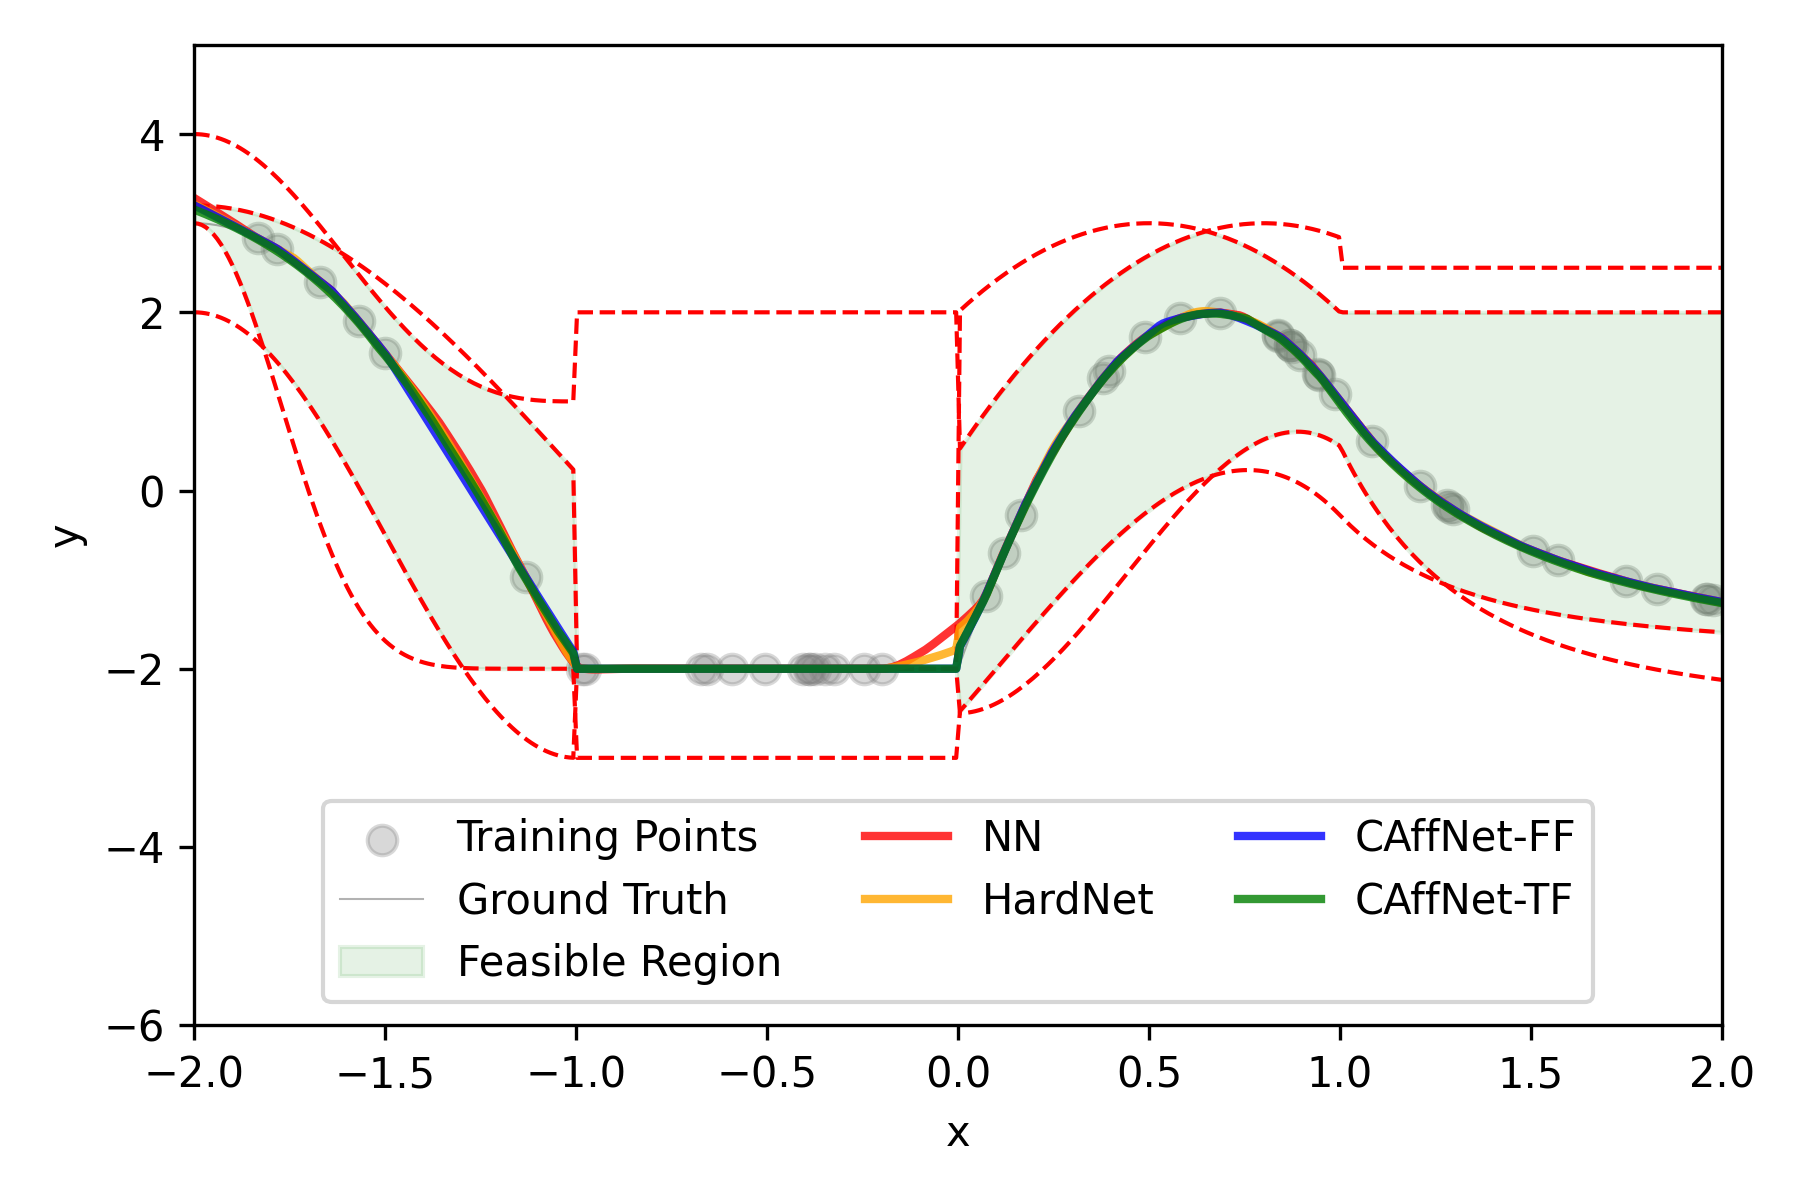

In [4]:
result_png = f"result_seed_{PLOT_SEED}.png"
fig, _ = result.plot_results(METHODS, filename=result_png, output_dir=OUTPUT_DIR, show_plot=False)
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / result_png)))

## Loss Plot From Seed 6

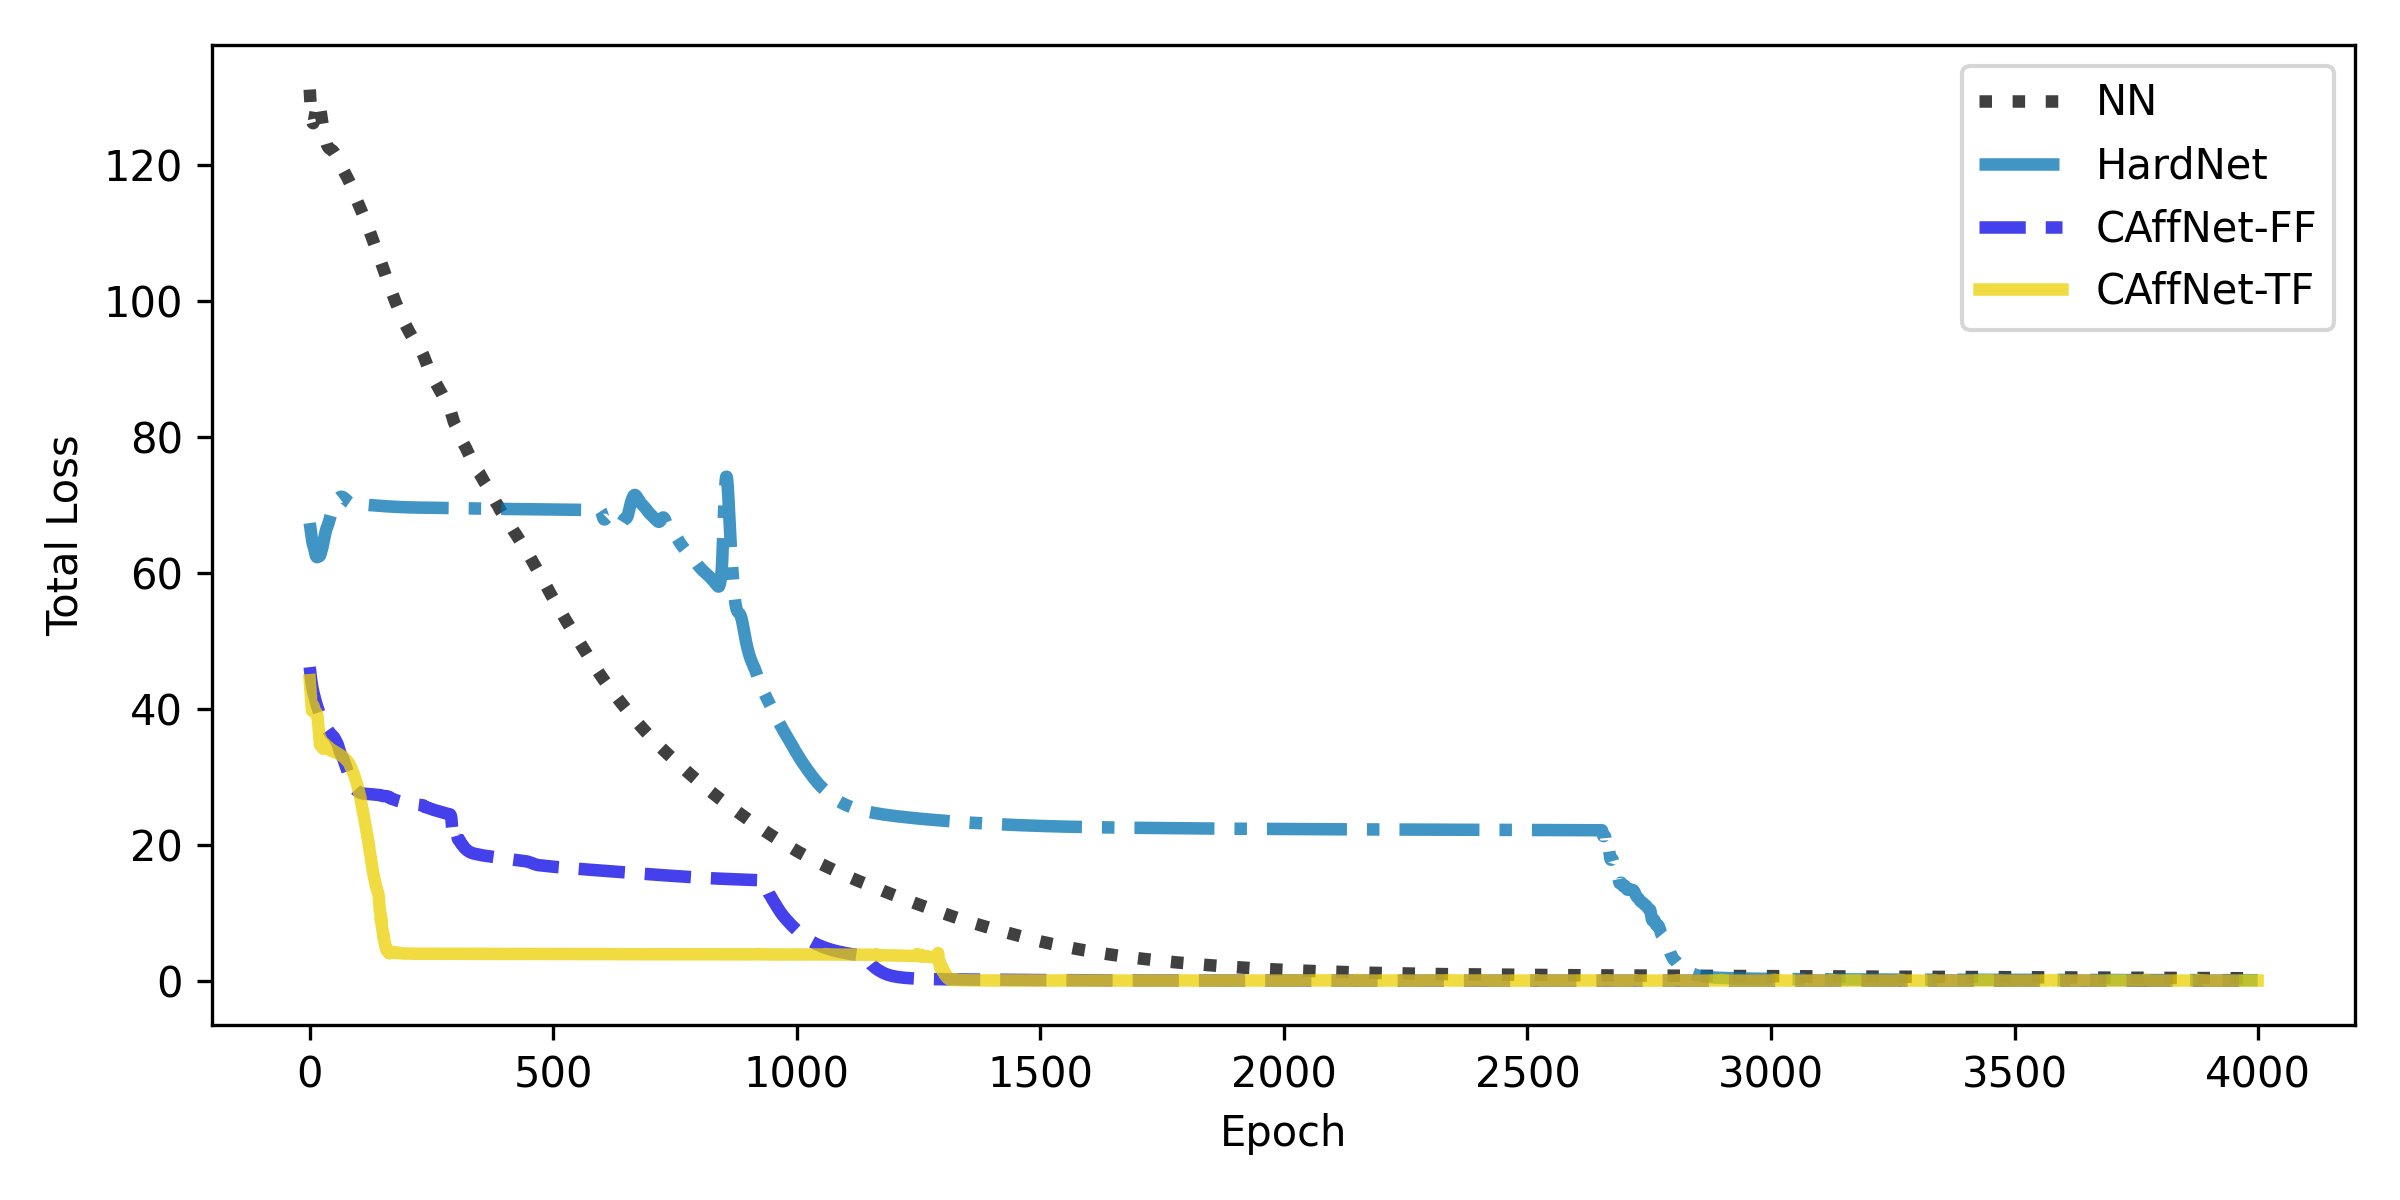

In [5]:
loss_png = f"loss_seed_{PLOT_SEED}.png"
fig, _ = result.plot_loss(METHODS, filename=loss_png, output_dir=OUTPUT_DIR, show_plot=False)
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / loss_png)))